<a href="https://colab.research.google.com/github/22126037-ui/BIG-DATA-NHOM-7/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# VI.1.1. CẤU HÌNH CHUNG

import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 1. Download dataset từ Kaggle
print("Đang tải dataset từ Kaggle...")
path_dir = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(f"Dataset đã tải về tại: {path_dir}")

# 2. Định nghĩa đường dẫn các file
base_path = path_dir

orders = pd.read_csv(f"{base_path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base_path}/olist_order_items_dataset.csv")
order_reviews = pd.read_csv(f"{base_path}/olist_order_reviews_dataset.csv")
customers = pd.read_csv(f"{base_path}/olist_customers_dataset.csv")
products = pd.read_csv(f"{base_path}/olist_products_dataset.csv")
order_payments = pd.read_csv(f"{base_path}/olist_order_payments_dataset.csv")
sellers = pd.read_csv(f"{base_path}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{base_path}/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(f"{base_path}/product_category_name_translation.csv")

print("✅ Load thành công tất cả 9 file CSV!")
print(f"Shape của các bảng chính:")
print(f"  - orders        : {orders.shape}")
print(f"  - order_items   : {order_items.shape}")
print(f"  - order_reviews : {order_reviews.shape}")
print(f"  - customers     : {customers.shape}")

Đang tải dataset từ Kaggle...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset đã tải về tại: /kaggle/input/brazilian-ecommerce
✅ Load thành công tất cả 9 file CSV!
Shape của các bảng chính:
  - orders        : (99441, 8)
  - order_items   : (112650, 7)
  - order_reviews : (99224, 7)
  - customers     : (99441, 5)


In [2]:
# 3. Merge dữ liệu cần thiết
# Bắt đầu từ order_reviews
df = order_reviews[['order_id', 'review_score']].copy()

# Merge với orders để lấy thời gian và customer
df = df.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp',
                      'order_status']], on='order_id', how='left')

# Merge với customers
df = df.merge(customers[['customer_id', 'customer_unique_id', 'customer_city',
                         'customer_state']], on='customer_id', how='left')

# Merge với order_items để lấy thông tin sản phẩm và giá
items = order_items.groupby('order_id').agg({
    'product_id': 'first',           # lấy sản phẩm đầu tiên nếu có nhiều
    'price': 'sum',
    'freight_value': 'sum',
    'order_item_id': 'count'         # số lượng sản phẩm trong đơn
}).reset_index().rename(columns={'order_item_id': 'item_count'})

df = df.merge(items, on='order_id', how='left')

# Merge với products và category translation
df = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

# Merge payment type (lấy payment_type phổ biến nhất trong đơn)
payments = order_payments.groupby('order_id')['payment_type'].agg(lambda x: x.mode()[0] if not x.empty else np.nan).reset_index()
df = df.merge(payments, on='order_id', how='left')

print(f"\nShape sau khi merge: {df.shape}")
print(df.head())


Shape sau khi merge: (99224, 15)
                           order_id  review_score  \
0  73fc7af87114b39712e6da79b0a377eb             4   
1  a548910a1c6147796b98fdf73dbeba33             5   
2  f9e4b658b201a9f2ecdecbb34bed034b             5   
3  658677c97b385a9be170737859d3511b             5   
4  8e6bfb81e283fa7e4f11123a3fb894f1             5   

                        customer_id order_purchase_timestamp order_status  \
0  41dcb106f807e993532d446263290104      2018-01-11 15:30:49    delivered   
1  8a2e7ef9053dea531e4dc76bd6d853e6      2018-02-28 12:25:19    delivered   
2  e226dfed6544df5b7b87a48208690feb      2018-02-03 09:56:22    delivered   
3  de6dff97e5f1ba84a3cd9a3bc97df5f6      2017-04-09 17:41:13    delivered   
4  5986b333ca0d44534a156a52a8e33a83      2018-02-10 10:59:03    delivered   

                 customer_unique_id           customer_city customer_state  \
0  68a5590b9926689be4e10f4ae2db21a8                  osasco             SP   
1  64190b91b656ab8f37eb89b93

In [3]:
# 4. Tạo Target: review_score_binary
df['review_score_binary'] = np.where(df['review_score'] >= 4, 1, 0)

print("\nPhân bố của Target (review_score_binary):")
print(df['review_score_binary'].value_counts(normalize=True))


Phân bố của Target (review_score_binary):
review_score_binary
1    0.77068
0    0.22932
Name: proportion, dtype: float64


In [ ]:
# Preprocessing pipeline
categorical_features = ['payment_type', 'customer_state', 'product_category_name']
numeric_features = [col for col in X.columns if col not in categorical_features]

# --- START OF FIX ---
# Ensure all numeric_features are truly numeric and handle any 'missing' strings from previous fillna
for col in numeric_features:
    # Attempt to convert column to numeric, coercing any non-numeric values (like 'missing') to NaN
    X[col] = pd.to_numeric(X[col], errors='coerce')
    # If NaNs are present after coercion or from original data, fill them with the column's median
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median()) # Using median for numeric imputation
# --- END OF FIX ---

# Label encode categorical features BEFORE splitting and applying ColumnTransformer
# This is necessary because ColumnTransformer's 'passthrough' for 'cat' features expects them already processed.
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Split 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Now, define and apply the ColumnTransformer for scaling numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)
    ],
    remainder='passthrough' # Handle any columns not specified (shouldn't be any here)
)

# Apply the preprocessor to X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Train shape (after preprocessing):", X_train_processed.shape, "Test shape (after preprocessing):", X_test_processed.shape)

# ====================== 5 MODELS ======================
models = {
    "1. LogisticRegression": LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    "2. RandomForestClassifier": RandomForestClassifier(n_estimators=200, max_depth=15, max_features='sqrt', random_state=42),
    "3. GaussianNB": GaussianNB(var_smoothing=1e-9),
    "4. SVC": SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42),
    "5. GradientBoostingClassifier": GradientBoostingClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, subsample=0.8, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"ĐANG TRAIN {name}")
    print(f"Hyperparameters: {model.get_params()}")

    # Cross-validation 5-fold using processed data
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='f1')
    print(f"CV F1-score (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Train & Predict using processed data
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Test Accuracy : {acc:.4f}")
    print(f"Test F1-score : {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    results[name] = {'accuracy': acc, 'f1': f1, 'cv_f1': cv_scores.mean()}

# So sánh tổng
print("\n BẢNG SO SÁNH 5 MODELS")
print(pd.DataFrame(results).T.round(4))

Train shape (after preprocessing): (79379, 12) Test shape (after preprocessing): (19845, 12)

ĐANG TRAIN 1. LogisticRegression
Hyperparameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
CV F1-score (5-fold): 0.8907 ± 0.0009
Test Accuracy : 0.8199
Test F1-score : 0.8912

Classification Report:
               precision    recall  f1-score   support

    Negative       0.71      0.36      0.48      4551
    Positive       0.83      0.96      0.89     15294

    accuracy                           0.82     19845
   macro avg       0.77      0.66      0.68     19845
weighted avg       0.81      0.82      0.80     19845


ĐANG TRAIN 2. RandomForestClassifier
Hyperparameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'm

In [4]:
# 5. Chuẩn bị X, y và Train/Test Split
features = ['price', 'freight_value', 'item_count', 'customer_state',
            'product_category_name_english', 'payment_type']

X = df[features].copy()
y = df['review_score_binary'].copy()

# Xử lý missing value tạm thời (sau này sẽ cải tiến)
X = X.fillna({
    'price': X['price'].median(),
    'freight_value': X['freight_value'].median(),
    'item_count': 1,
    'customer_state': 'unknown',
    'product_category_name_english': 'unknown',
    'payment_type': 'unknown'
})

# Áp dụng One-Hot Encoding cho các cột phân loại
X = pd.get_dummies(X, columns=['customer_state', 'product_category_name_english', 'payment_type'], drop_first=True)

# Train/Test split theo đúng yêu cầu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\n✅ Train shape: {X_train.shape}")
print(f"✅ Test shape : {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate : {y_test.mean():.4f}")


✅ Train shape: (79379, 105)
✅ Test shape : (19845, 105)
Train positive rate: 0.7707
Test positive rate : 0.7707


Đang huấn luyện mô hình Logistic Regression...
Thời gian huấn luyện: 58.38 giây
Thời gian dự đoán: 0.09 giây
Tổng thời gian: 58.46 giây


CLASSIFICATION REPORT - LOGISTIC REGRESSION
              precision    recall  f1-score   support

Class 0 (≤3)     0.4260    0.0209    0.0398      4551
Class 1 (≥4)     0.7729    0.9916    0.8687     15294

    accuracy                         0.7690     19845
   macro avg     0.5995    0.5063    0.4543     19845
weighted avg     0.6934    0.7690    0.6786     19845


CONFUSION MATRIX:
[[   95  4456]
 [  128 15166]]


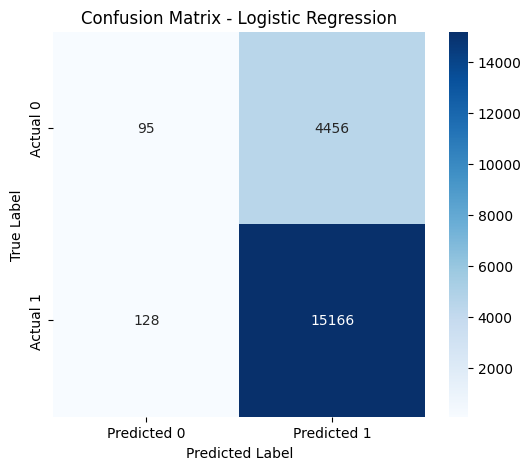


AUC - ROC Score: 0.6113


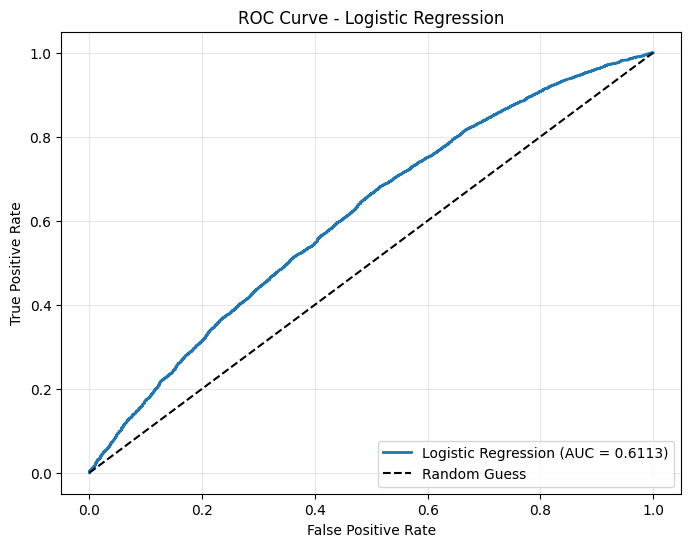

In [5]:
# ============================
# VI.1.2. LOGISTIC REGRESSION (Đã bổ sung Time & AUC-ROC)
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Đang huấn luyện mô hình Logistic Regression...")

# ====================== Đo thời gian huấn luyện ======================
start_time = time.time()

lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42,
    solver='lbfgs'
)

lr.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Thời gian huấn luyện: {train_time:.2f} giây")

# Dự đoán trên tập Test
start_pred = time.time()
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]   # Xác suất lớp 1
pred_time = time.time() - start_pred

print(f"Thời gian dự đoán: {pred_time:.2f} giây")
print(f"Tổng thời gian: {train_time + pred_time:.2f} giây\n")

# ====================== Đánh giá mô hình ======================
print("\n" + "="*70)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("="*70)
print(classification_report(y_test, y_pred, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

# Confusion Matrix
print("\nCONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ====================== AUC - ROC ======================
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC - ROC Score: {auc_score:.4f}")

# Vẽ đường cong ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Đang huấn luyện mô hình Random Forest...

CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

Class 0 (≤3)     0.7636    0.0277    0.0534      4551
Class 1 (≥4)     0.7752    0.9974    0.8724     15294

    accuracy                         0.7751     19845
   macro avg     0.7694    0.5126    0.4629     19845
weighted avg     0.7725    0.7751    0.6846     19845


CONFUSION MATRIX - Random Forest:
[[  126  4425]
 [   39 15255]]


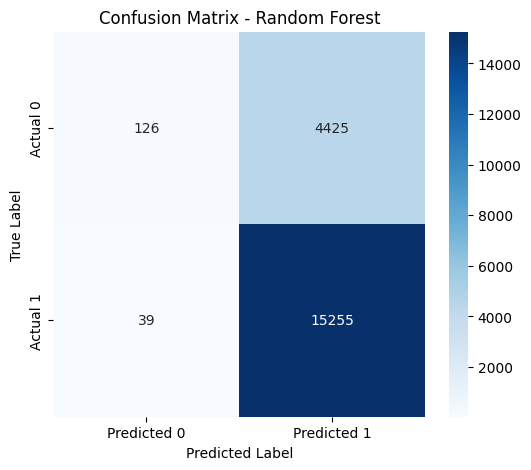


AUC-ROC Score: 0.6154


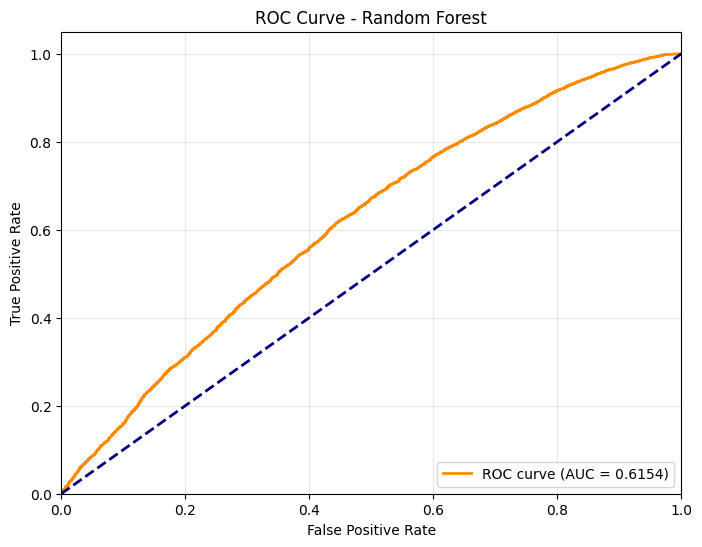


Time (s): 15.38 seconds

Top 10 Feature Importance (Random Forest):
                                            Feature  Importance
1                                     freight_value    0.285069
0                                             price    0.251218
2                                        item_count    0.123871
98            product_category_name_english_unknown    0.078071
20                                customer_state_RJ    0.024546
100                        payment_type_credit_card    0.021330
27                                customer_state_SP    0.017074
85   product_category_name_english_office_furniture    0.010698
104                            payment_type_voucher    0.009382
35     product_category_name_english_bed_bath_table    0.008073


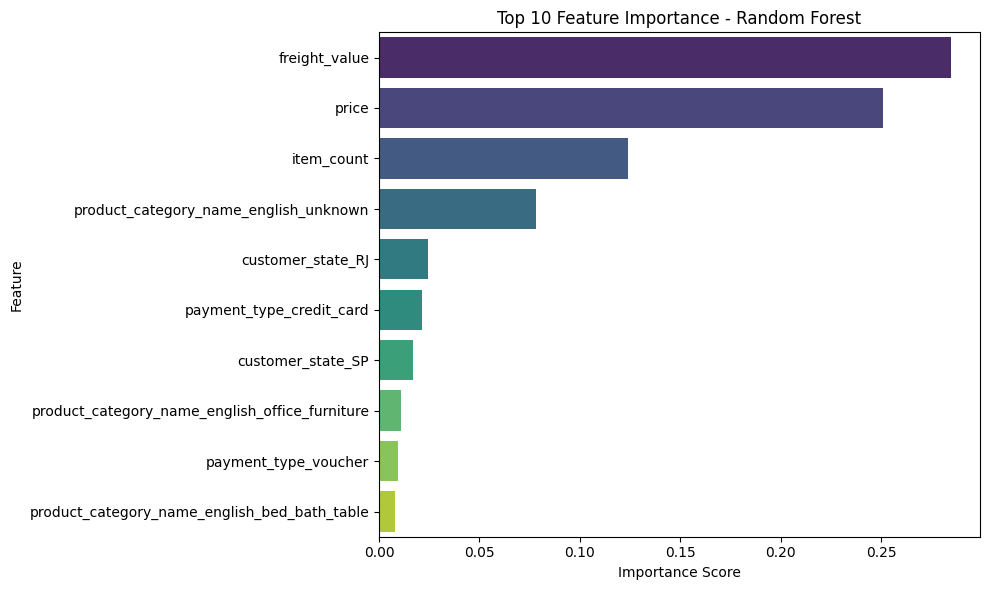

In [6]:
# VI.1.3. RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_auc_score,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

print("Đang huấn luyện mô hình Random Forest...")

# ==================== ĐO THỜI GIAN ====================
start_time = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Thời gian huấn luyện + dự đoán
train_pred_time = time.time() - start_time

# Dự đoán trên tập Test
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]   # Xác suất lớp dương (class 1)

# ==================== ĐÁNH GIÁ MÔ HÌNH ====================
print("\n" + "="*75)
print("CLASSIFICATION REPORT - RANDOM FOREST")
print("="*75)
print(classification_report(y_test, y_pred_rf,
                          digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

# Confusion Matrix
print("\nCONFUSION MATRIX - Random Forest:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ==================== AUC-ROC ====================
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nAUC-ROC Score: {auc_rf:.4f}")

# Vẽ đường cong ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ==================== THỜI GIAN ====================
print(f"\nTime (s): {train_pred_time:.2f} seconds")

# ==================== FEATURE IMPORTANCE ====================
print("\nTop 10 Feature Importance (Random Forest):")
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# ============================
# VI.1.4. GAUSSIANNB, SVC, GRADIENT BOOSTING (Phiên bản tối ưu tốc độ)
# ============================

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

print("Đang huấn luyện 3 mô hình: GaussianNB, SVC, Gradient Boosting...\n")

# ====================== 1. Gaussian Naive Bayes ======================
print("1. GaussianNB")
start = time.time()

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
y_pred_proba_gnb = gnb.predict_proba(X_test)[:, 1]   # Dùng để tính AUC-ROC

time_gnb = time.time() - start

print("Classification Report - GaussianNB")
print(classification_report(y_test, y_pred_gnb, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

auc_gnb = roc_auc_score(y_test, y_pred_proba_gnb)
print(f"AUC-ROC Score     : {auc_gnb:.4f}")
print(f"Time (s)          : {time_gnb:.2f} giây\n")

# ====================== 2. Support Vector Classifier (SVC) ======================
print("2. SVC (RBF kernel)")
start = time.time()

svc = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,         # BẬT probability để tính được AUC-ROC
    random_state=42,
    max_iter=500,
    tol=1e-3
)

svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
y_pred_proba_svc = svc.predict_proba(X_test)[:, 1]

time_svc = time.time() - start

print("Classification Report - SVC")
print(classification_report(y_test, y_pred_svc, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

auc_svc = roc_auc_score(y_test, y_pred_proba_svc)
print(f"AUC-ROC Score     : {auc_svc:.4f}")
print(f"Time (s)          : {time_svc:.2f} giây\n")

# ====================== 3. Gradient Boosting ======================
print("3. Gradient Boosting")
start = time.time()

gbt = GradientBoostingClassifier(
    n_estimators=80,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    subsample=0.8
)

gbt.fit(X_train, y_train)
y_pred_gbt = gbt.predict(X_test)
y_pred_proba_gbt = gbt.predict_proba(X_test)[:, 1]

time_gbt = time.time() - start

print("Classification Report - Gradient Boosting")
print(classification_report(y_test, y_pred_gbt, digits=4,
                          target_names=['Class 0 (≤3)', 'Class 1 (≥4)']))

auc_gbt = roc_auc_score(y_test, y_pred_proba_gbt)
print(f"AUC-ROC Score     : {auc_gbt:.4f}")
print(f"Time (s)          : {time_gbt:.2f} giây\n")

# ====================== Confusion Matrix & Feature Importance (Gradient Boosting) ======================
print("\n" + "="*60)
print("CONFUSION MATRIX - Gradient Boosting")
print("="*60)
cm_gbt = confusion_matrix(y_test, y_pred_gbt)
print(cm_gbt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gbt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance
print("\nTop 10 Feature Importance - Gradient Boosting:")
feature_names = X_train.columns.tolist()
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gbt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')
plt.title('Top 10 Feature Importance - Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ====================== ROC Curve cho cả 3 mô hình ======================
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# GaussianNB
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_gnb)
plt.plot(fpr, tpr, label=f'GaussianNB (AUC = {auc_gnb:.4f})')

# SVC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_svc)
plt.plot(fpr, tpr, label=f'SVC (AUC = {auc_svc:.4f})')

# Gradient Boosting
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_gbt)
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc_gbt:.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Đang huấn luyện 3 mô hình: GaussianNB, SVC, Gradient Boosting...

1. GaussianNB
Classification Report - GaussianNB
              precision    recall  f1-score   support

Class 0 (≤3)     0.3147    0.2837    0.2984      4551
Class 1 (≥4)     0.7929    0.8162    0.8044     15294

    accuracy                         0.6941     19845
   macro avg     0.5538    0.5499    0.5514     19845
weighted avg     0.6833    0.6941    0.6884     19845

AUC-ROC Score     : 0.5842
Time (s)          : 0.66 giây

2. SVC (RBF kernel)
